In [1]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download amirmotefaker/supply-chain-dataset

Dataset URL: https://www.kaggle.com/datasets/amirmotefaker/supply-chain-dataset
License(s): other


In [3]:
!unzip supply-chain-dataset.zip -d data

Archive:  supply-chain-dataset.zip
  inflating: data/supply_chain_data.csv  


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from scipy.stats import pearsonr

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('/content/data/supply_chain_data.csv')
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

## **Data Visualizations**

In [8]:
sales_agg = df.groupby('Product type').agg(
      SKU=('SKU', 'count'),
      Total_products_sold=('Number of products sold', 'sum'),
      Revenue= ('Revenue generated', 'sum'),
      ).assign(
        Total_products_sold_percentage=lambda x: x['Total_products_sold'] / x['Total_products_sold'].sum() * 100,
        Revenue_percentage=lambda x: x['Revenue'] / x['Revenue'].sum() * 100,
    ).sort_values(by=['Total_products_sold', 'Revenue'], ascending=False)

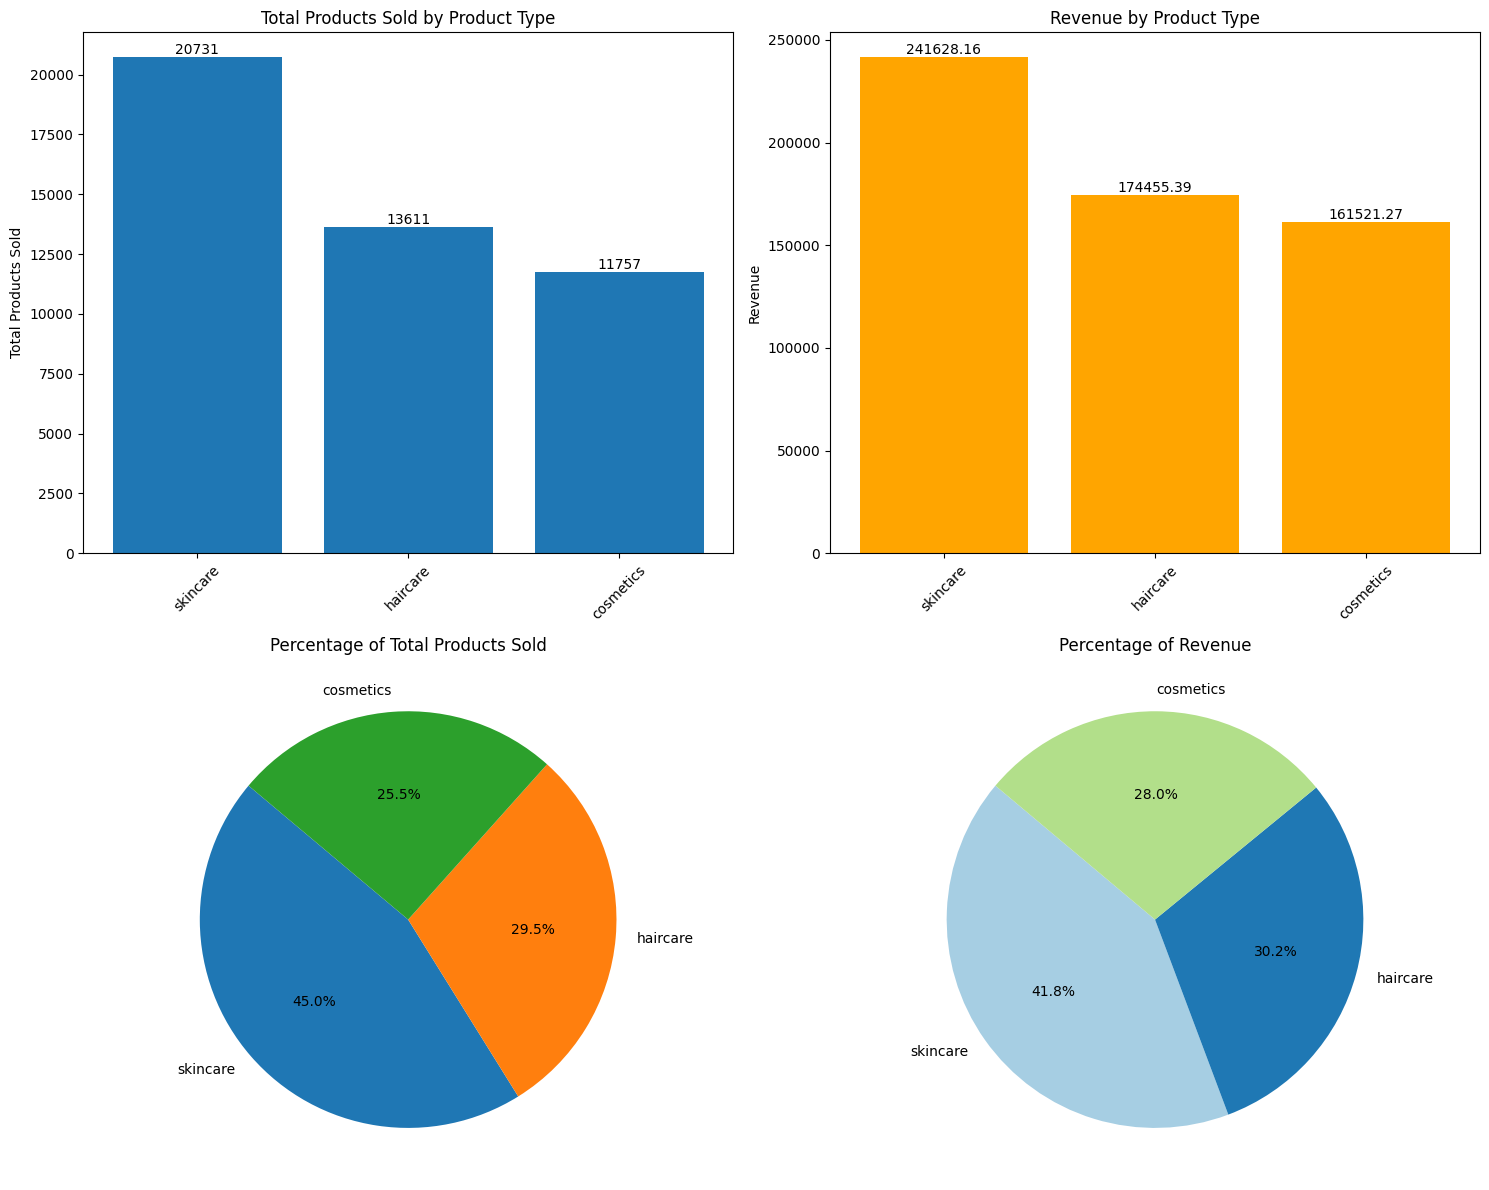

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Bar Chart 1: Total Products Sold
bars1 = axes[0, 0].bar(sales_agg.index, sales_agg['Total_products_sold'])
axes[0, 0].set_title('Total Products Sold by Product Type')
axes[0, 0].set_ylabel('Total Products Sold')
axes[0, 0].tick_params(axis='x', rotation=45)

for bar in bars1:
    yval = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Bar Chart 2: Revenue
bars2 = axes[0, 1].bar(sales_agg.index, sales_agg['Revenue'], color='orange')
axes[0, 1].set_title('Revenue by Product Type')
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].tick_params(axis='x', rotation=45)

for bar in bars2:
    yval = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Pie Chart 1: Percentage of Total Products Sold
axes[1, 0].pie(sales_agg['Total_products_sold_percentage'], labels=sales_agg.index, autopct='%1.1f%%', startangle=140)
axes[1, 0].set_title('Percentage of Total Products Sold')

# Pie Chart 2: Percentage of Revenue
axes[1, 1].pie(sales_agg['Revenue_percentage'], labels=sales_agg.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
axes[1, 1].set_title('Percentage of Revenue')

# Adjust layout and display
plt.tight_layout()
plt.show()

**Observations**
* Skincare dominates both sales volume (45%) and revenue (41.8%), confirming its market leadership and highlighting its potential as the primary driver for business growth.
* Haircare and cosmetics show a higher revenue percentage compared to sales volume, indicating higher pricing or margins; strategic focus on these categories could boost profitability despite lower unit sales.

<ipython-input-10-81a80b66e9fb>:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right') # Use set_xticklabels to rotate and align labels


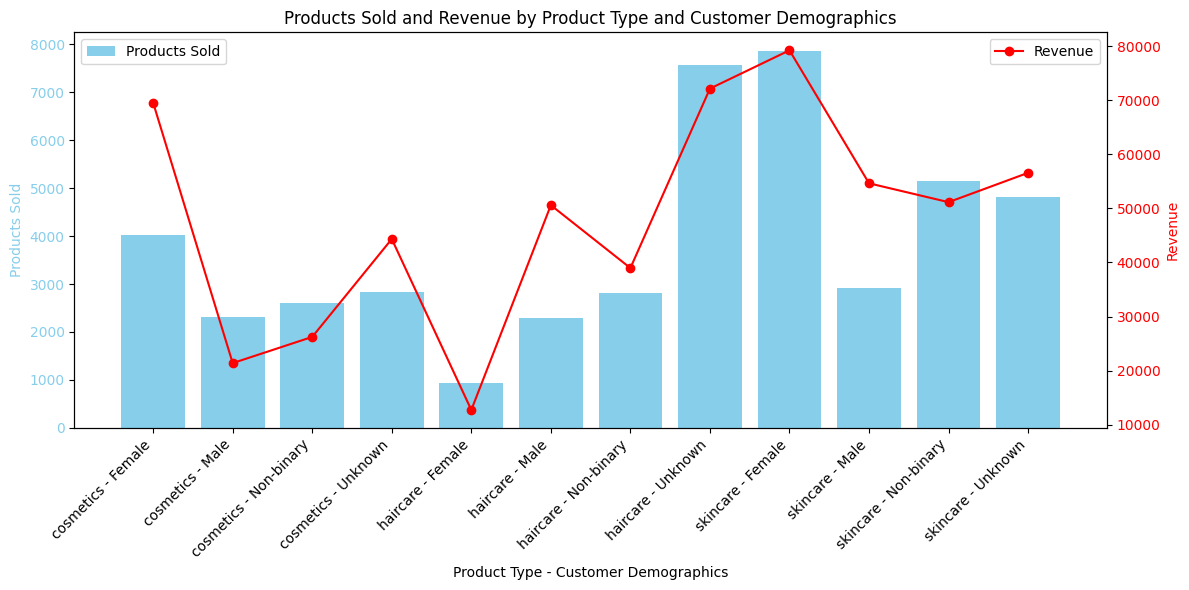

In [10]:
# Group data for plotting
demograph = df.groupby(['Product type', 'Customer demographics']).agg({'Number of products sold': 'sum', 'Revenue generated': 'sum'}).reset_index()

# Group data for plotting
demograph = df.groupby(['Product type', 'Customer demographics']).agg({'Number of products sold': 'sum', 'Revenue generated': 'sum'}).reset_index()

# Create the bar chart and line chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Products Sold
ax1.bar(demograph['Product type'] + ' - ' + demograph['Customer demographics'], demograph['Number of products sold'], color='skyblue', label='Products Sold')
ax1.set_xlabel('Product Type - Customer Demographics')
ax1.set_ylabel('Products Sold', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
# Changed line to rotate x-axis tick labels and align them to the right:
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right') # Use set_xticklabels to rotate and align labels

# Create a second y-axis for Revenue
ax2 = ax1.twinx()
ax2.plot(demograph['Product type'] + ' - ' + demograph['Customer demographics'], demograph['Revenue generated'], color='red', marker='o', label='Revenue')
ax2.set_ylabel('Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Title and display
plt.title('Products Sold and Revenue by Product Type and Customer Demographics')
plt.tight_layout()
plt.show()

**Observation**

The "skincare - Female" demographic shows the highest revenue and product sales, indicating a strong preference for skincare products among female customers.  "Haircare" products, particularly for the "Male" and "Non-binary" demographics, show significantly lower revenue and sales compared to other categories.

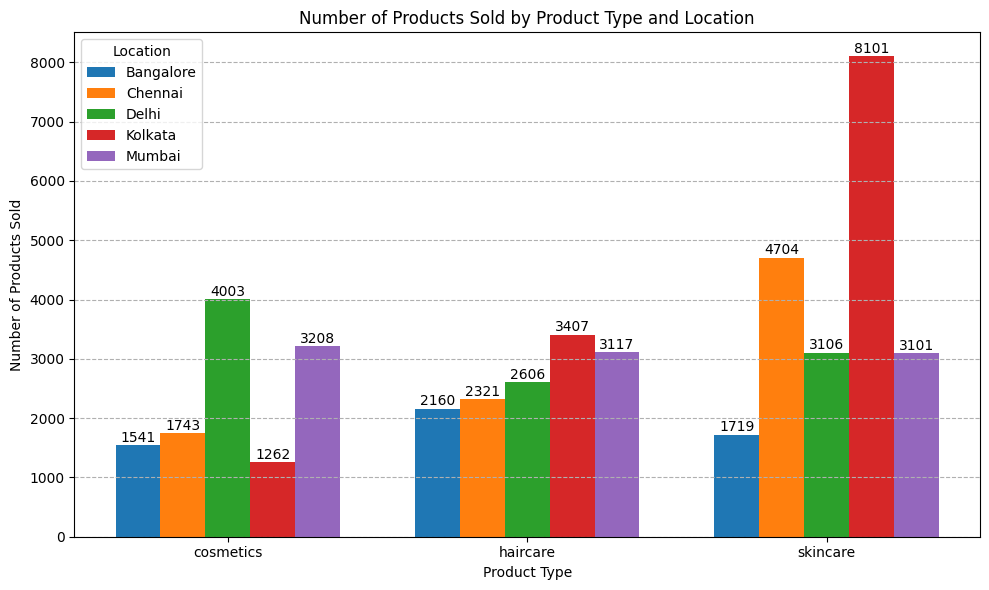

In [11]:
# Group data by Product type and Location to get total sales for each combination
grouped_data = df.groupby(['Product type', 'Location'])['Number of products sold'].sum().unstack(fill_value=0)

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting each product type as a group of bars
bar_width = 0.15
x = np.arange(len(grouped_data.index))

for i, location in enumerate(grouped_data.columns):
    bars = ax.bar(x + i * bar_width, grouped_data[location], bar_width, label=location)
    # Add numbers on top of each bar
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 2), ha='center', va='bottom')

# Set labels and title
ax.set_xlabel('Product Type')
ax.set_ylabel('Number of Products Sold')
ax.set_title('Number of Products Sold by Product Type and Location')
ax.set_xticks(x + (len(grouped_data.columns) - 1) * bar_width / 2)
ax.set_xticklabels(grouped_data.index)
ax.legend(title='Location')
ax.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

**Observations:**
1. Skincare leads in Kolkata: Kolkata shows the highest number of products sold for skincare, reaching approximately 8101 units, significantly outperforming other locations for this product type.

2. Delhi dominates cosmetics: Delhi has the highest sales for cosmetics at around 4003 units, considerably more than other locations for this category.

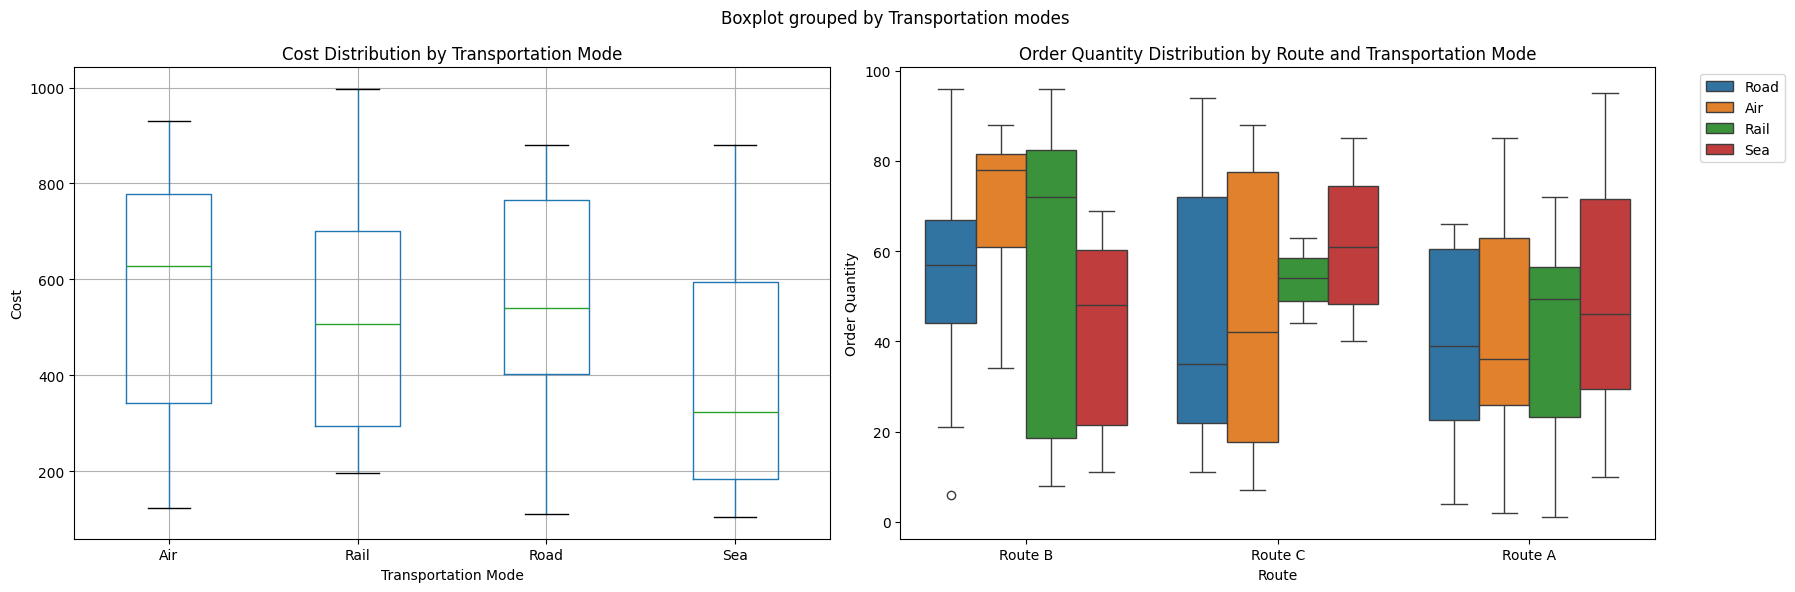

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 1. Box Plot: Cost distribution by Transportation Mode
df.boxplot(column='Costs', by='Transportation modes', ax=axes[0])
axes[0].set_title('Cost Distribution by Transportation Mode')
axes[0].set_xlabel('Transportation Mode')
axes[0].set_ylabel('Cost')

# 2. Box Plot: Order Quantity distribution by Route and Transportation Mode
sns.boxplot(x='Routes', y='Order quantities', hue='Transportation modes', data=df, ax=axes[1])
axes[1].set_title('Order Quantity Distribution by Route and Transportation Mode')
axes[1].set_xlabel('Route')
axes[1].set_ylabel('Order Quantity')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Observations:**

*Cost Distribution by Transportation Mode:*

* Air transport has the highest median cost (around 625) and the widest cost range (from approximately 125 to 950).

* Sea transport has the lowest median cost (around 325) and a relatively smaller cost range (from roughly 100 to 600).

*Order Quantity Distribution by Route and Transportation Mode:*

* Route B shows the highest median order quantity for Air transport (around 80) and Rail transport (around 60), while Road transport has a lower median (around 45) and Sea transport has the lowest (around 20).

* Route C exhibits a relatively consistent median order quantity across all transportation modes, ranging from approximately 55 to 70.

* Route A has a higher median order quantity for Sea transport (around 60) and Rail transport (around 55) compared to Road (around 55) and Air (around 40).

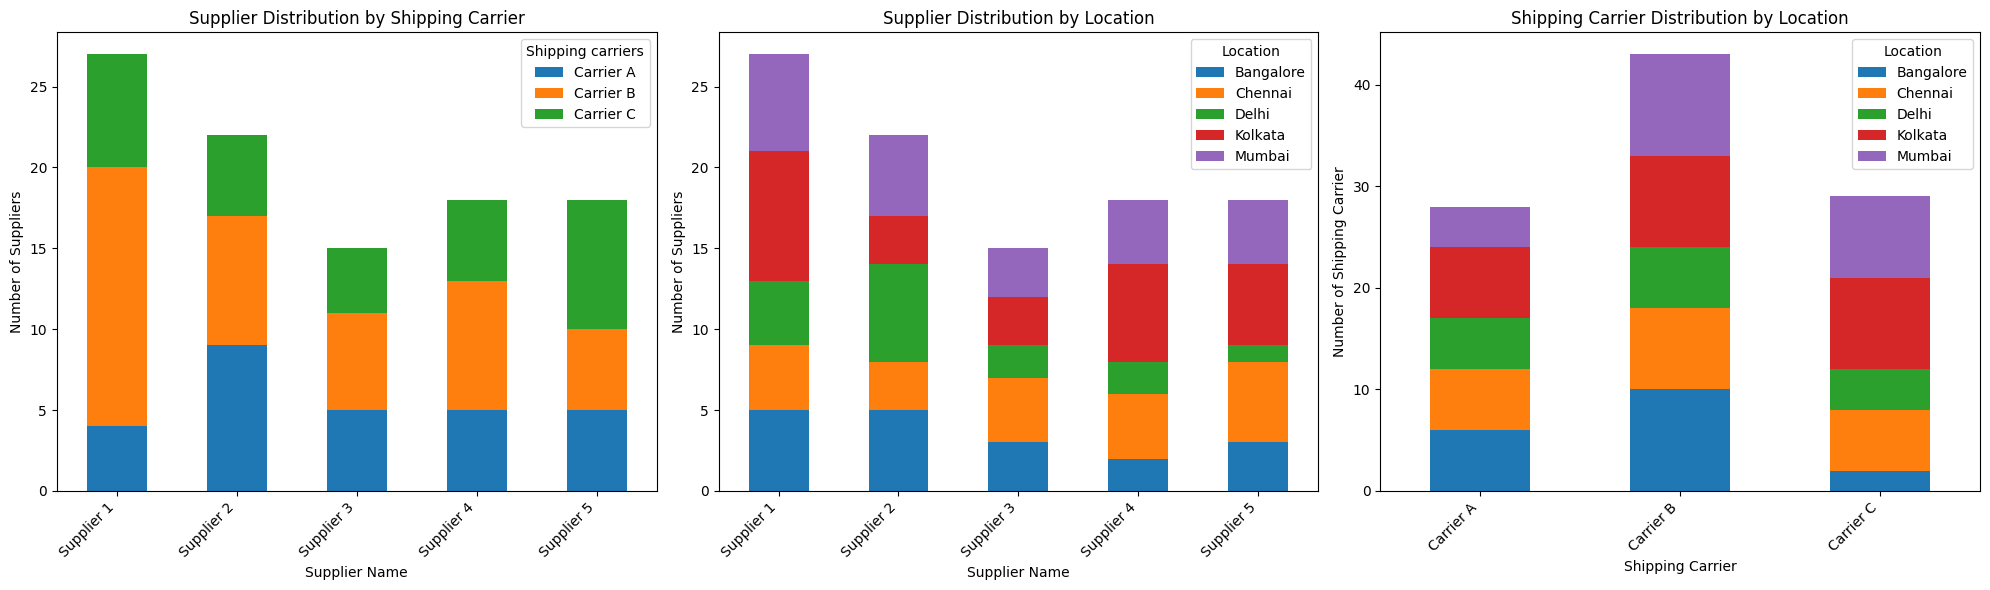

In [14]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# 1. Supplier vs. Shipping Carrier (Count Plot)
supplier_carrier_counts = df.groupby(['Supplier name', 'Shipping carriers'])['Supplier name'].count().unstack(fill_value=0)
supplier_carrier_counts.plot(kind='bar', ax=axes[0], stacked=True)  # Use stacked bar plot
axes[0].set_title('Supplier Distribution by Shipping Carrier')
axes[0].set_xlabel('Supplier Name')
axes[0].set_ylabel('Number of Suppliers')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# 2. Supplier vs. Location (Count Plot)
supplier_location_counts = df.groupby(['Supplier name', 'Location'])['Supplier name'].count().unstack(fill_value=0)
supplier_location_counts.plot(kind='bar', ax=axes[1], stacked=True)  # Use stacked bar plot
axes[1].set_title('Supplier Distribution by Location')
axes[1].set_xlabel('Supplier Name')
axes[1].set_ylabel('Number of Suppliers')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# 3. Shipping Carrier vs. Location (Count Plot)
carrier_location_counts = df.groupby(['Shipping carriers', 'Location'])['Shipping carriers'].count().unstack(fill_value=0)
carrier_location_counts.plot(kind='bar', ax=axes[2], stacked=True)  # Use stacked bar plot
axes[2].set_title('Shipping Carrier Distribution by Location')
axes[2].set_xlabel('Shipping Carrier')
axes[2].set_ylabel('Number of Shipping Carrier')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Observations:**

* Carrier A dominates in terms of the number of suppliers: The first graph clearly shows that Carrier A consistently has the highest number of suppliers associated with it across all listed suppliers.

* Bangalore and Mumbai have a significant number of suppliers: The second graph indicates that Bangalore and Mumbai tend to have a higher number of suppliers compared to Chennai, Delhi, and Kolkata.

* Shipping Carrier B handles the most shipping carriers from Bangalore and Mumbai: The third graph reveals that Shipping Carrier B manages the largest volume of shipping carriers originating from both Bangalore and Mumbai.

## **Hypotheses Tests**

### **1. Hypothesis: Integrated cost efficiency and revenue per customer segment**

* H0 (Null Hypothesis): There is no relationship between integrated cost efficiency (considering manufacturing, logistics) and the average revenue generated per customer segment (defined by demographics).

* H1 (Alternative Hypothesis): Higher integrated cost efficiency (lower overall costs) is associated with higher average revenue generated per customer segment.



In [15]:
hyp_1 = df.copy()

# 1. Calculate Average Revenue per Customer Segment
hyp_1['Customer Segement'] = hyp_1['Customer demographics'] +'_'+ hyp_1['Location']
average_revenue = hyp_1.groupby('Customer Segement')['Revenue generated'].mean().reset_index()
average_revenue.rename(columns={'Revenue generated': 'Average Revenue'}, inplace=True)

# 2. Calculate Total Costs per Customer Segment
total_costs_segment = hyp_1.groupby('Customer Segement')['Costs'].sum().reset_index()
total_costs_segment.rename(columns={'Costs': 'Total Costs Segment'}, inplace=True) # Changed 'Total Costs' to 'Costs'

# Merge the aggregated data
merged_df = pd.merge(average_revenue, total_costs_segment, on='Customer Segement')

# 3. Calculate a Simple Integrated Cost Efficiency Metric
# (Lower value = Higher efficiency - using total cost per segment as a proxy for now)
merged_df['Integrated Cost Efficiency'] = merged_df['Total Costs Segment']

# --- Correlation Analysis ---
print("\n--- Correlation Analysis ---")

# Calculate Pearson correlation coefficient and p-value
# Note: We are correlating 'Integrated Cost Efficiency' (lower is better) with 'Average Revenue'
# We expect a negative correlation if higher efficiency leads to higher revenue.
correlation, p_value_corr = pearsonr(merged_df['Integrated Cost Efficiency'], merged_df['Average Revenue'])
print(f"Pearson Correlation Coefficient: {correlation:.3f}")
print(f"P-value: {p_value_corr:.3f}")

alpha = 0.05
if p_value_corr <= alpha:
    print(f"Since p-value ({p_value_corr:.3f}) <= alpha ({alpha}), we reject the Null Hypothesis.")
    print("There is a statistically significant linear relationship between integrated cost efficiency and average revenue per customer segment.")
    if correlation < 0:
        print("The negative correlation suggests that higher integrated cost efficiency (lower costs) is associated with higher average revenue.")
    elif correlation > 0:
        print("The positive correlation suggests that higher integrated cost efficiency (lower costs) is associated with lower average revenue (this might be counter-intuitive and requires further investigation).")
    else:
        print("There is no linear correlation observed.")
else:
    print(f"Since p-value ({p_value_corr:.3f}) > alpha ({alpha}), we fail to reject the Null Hypothesis.")
    print("There is no statistically significant linear relationship between integrated cost efficiency and average revenue per customer segment based on this data.")

# --- Regression Analysis ---
print("\n--- Regression Analysis ---")

# Prepare data for regression
regression_df = merged_df[['Average Revenue', 'Integrated Cost Efficiency']]

# Add a constant for the intercept
regression_df = sm.add_constant(regression_df)

# Fit the Ordinary Least Squares (OLS) regression model
# We are predicting 'Average Revenue' based on 'Integrated Cost Efficiency'
model = sm.OLS(regression_df['Average Revenue'], regression_df[['const', 'Integrated Cost Efficiency']]).fit()

# Print the regression results summary
print(model.summary())

# Interpret the coefficient for 'Integrated Cost Efficiency'
coefficient_cost_efficiency = model.params['Integrated Cost Efficiency']
p_value_reg_cost = model.pvalues['Integrated Cost Efficiency']

print(f"\nCoefficient for Integrated Cost Efficiency: {coefficient_cost_efficiency:.3f}")
print(f"P-value for Integrated Cost Efficiency Coefficient: {p_value_reg_cost:.3f}")

if p_value_reg_cost <= alpha:
    print(f"Since the p-value ({p_value_reg_cost:.3f}) for the Integrated Cost Efficiency coefficient is <= alpha ({alpha}), we reject the Null Hypothesis.")
    print("There is a statistically significant association between integrated cost efficiency and average revenue per customer segment.")
    if coefficient_cost_efficiency < 0:
        print("The negative coefficient indicates that as integrated cost efficiency (lower costs) increases, the average revenue tends to increase.")
    elif coefficient_cost_efficiency > 0:
        print("The positive coefficient indicates that as integrated cost efficiency (lower costs) increases, the average revenue tends to decrease (this might be counter-intuitive).")
else:
    print(f"Since the p-value ({p_value_reg_cost:.3f}) for the Integrated Cost Efficiency coefficient is > alpha ({alpha}), we fail to reject the Null Hypothesis.")
    print("There is no statistically significant linear relationship between integrated cost efficiency and average revenue per customer segment based on this regression model.")


--- Correlation Analysis ---
Pearson Correlation Coefficient: 0.416
P-value: 0.068
Since p-value (0.068) > alpha (0.05), we fail to reject the Null Hypothesis.
There is no statistically significant linear relationship between integrated cost efficiency and average revenue per customer segment based on this data.

--- Regression Analysis ---
                            OLS Regression Results                            
Dep. Variable:        Average Revenue   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     3.778
Date:                Sat, 12 Apr 2025   Prob (F-statistic):             0.0677
Time:                        03:42:22   Log-Likelihood:                -172.49
No. Observations:                  20   AIC:                             349.0
Df Residuals:                      18   BIC:                             351.0
Df Model:               

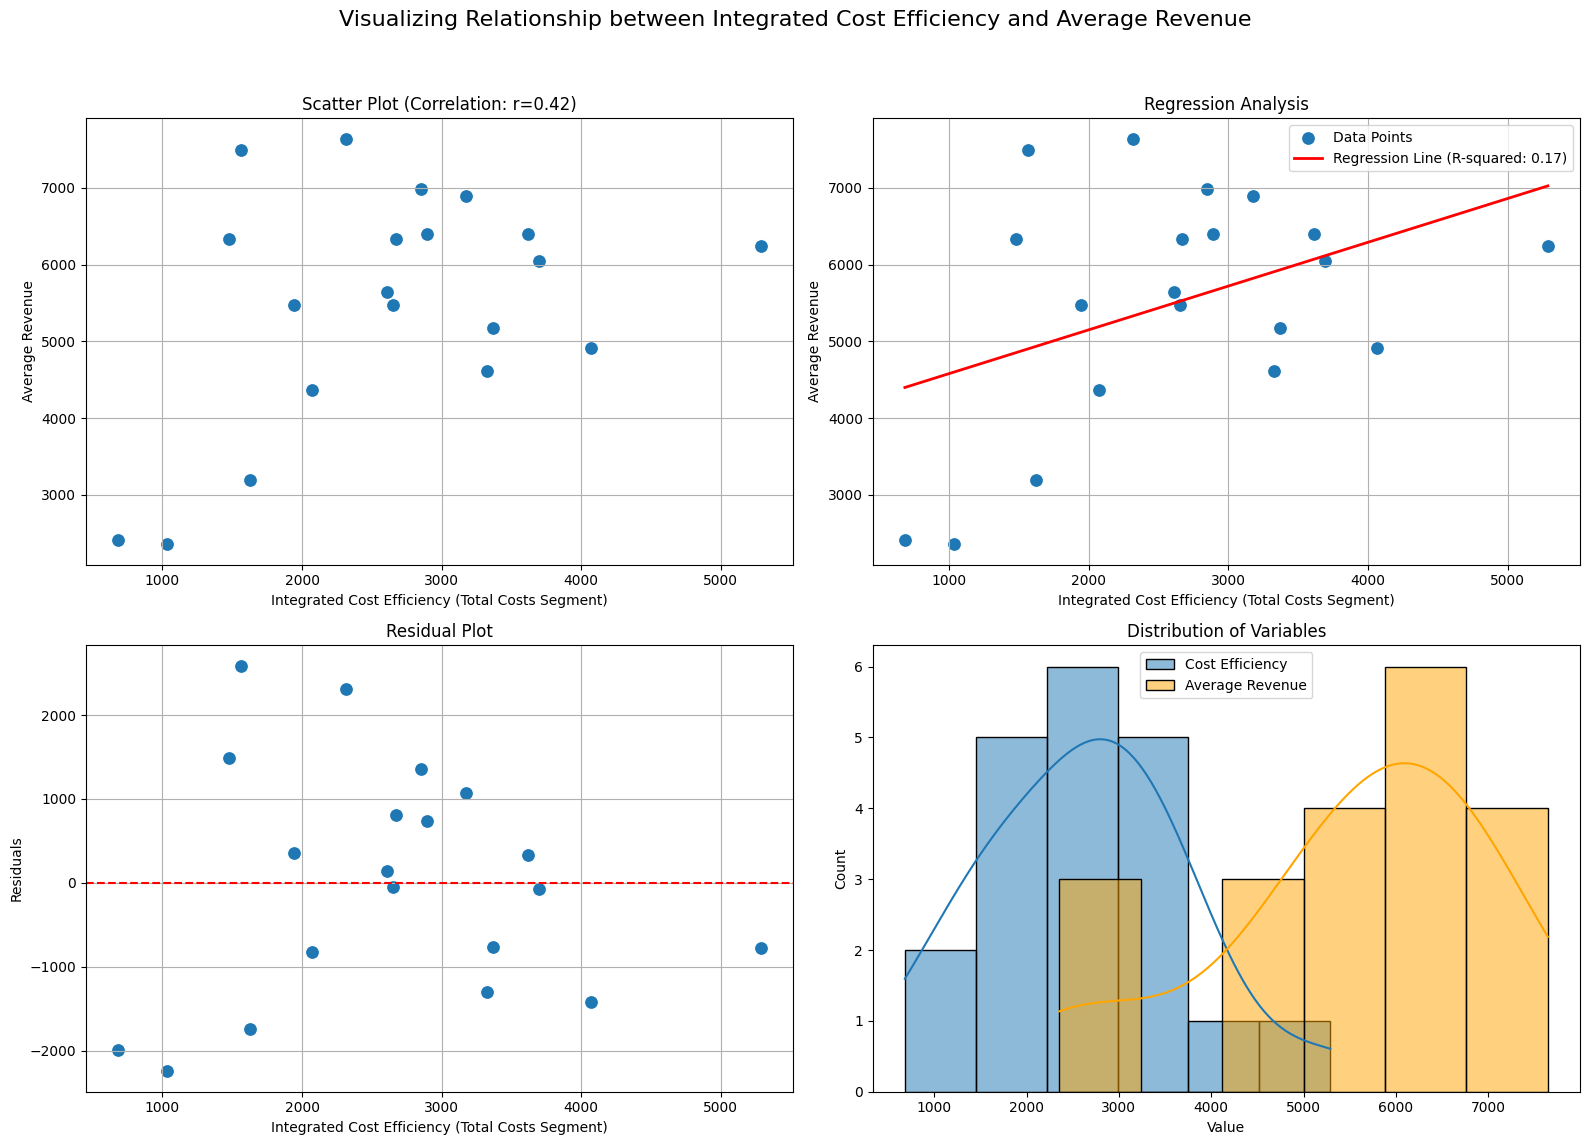

In [16]:
# --- Visualization with Subplots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Visualizing Relationship between Integrated Cost Efficiency and Average Revenue', fontsize=16)

# Subplot 1: Scatter Plot for Correlation
sns.scatterplot(ax=axes[0, 0], x=merged_df['Integrated Cost Efficiency'], y=merged_df['Average Revenue'], s=100)
axes[0, 0].set_title(f'Scatter Plot (Correlation: r={correlation:.2f})')
axes[0, 0].set_xlabel('Integrated Cost Efficiency (Total Costs Segment)')
axes[0, 0].set_ylabel('Average Revenue')
axes[0, 0].grid(True)

# Subplot 2: Regression Line
sns.scatterplot(ax=axes[0, 1], x=regression_df['Integrated Cost Efficiency'], y=regression_df['Average Revenue'], s=100, label='Data Points')
axes[0, 1].plot(regression_df['Integrated Cost Efficiency'].sort_values(), model.fittedvalues[regression_df['Integrated Cost Efficiency'].sort_values().index], color='red', linewidth=2, label=f'Regression Line (R-squared: {model.rsquared:.2f})')
axes[0, 1].set_title('Regression Analysis')
axes[0, 1].set_xlabel('Integrated Cost Efficiency (Total Costs Segment)')
axes[0, 1].set_ylabel('Average Revenue')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Subplot 3: Residual Plot
# Calculate residuals before using them in the scatterplot
residuals = model.resid
sns.scatterplot(ax=axes[1, 0], x=regression_df['Integrated Cost Efficiency'], y=residuals, s=100)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].set_xlabel('Integrated Cost Efficiency (Total Costs Segment)')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True)

# Subplot 4: Distribution of Variables
sns.histplot(ax=axes[1, 1], x=merged_df['Integrated Cost Efficiency'], kde=True, label='Cost Efficiency')
sns.histplot(ax=axes[1, 1], x=merged_df['Average Revenue'], kde=True, color='orange', label='Average Revenue')
axes[1, 1].set_title('Distribution of Variables')
axes[1, 1].set_xlabel('Value')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **2. Hypothesis: Supply Chain Velocity and Sales Performance**

* H0 (Null Hypothesis): The combined velocity of the supply chain (manufacturing lead time, shipping time, and stock availability) has no impact on sales revenue.

* H1 (Alternative Hypothesis): Increased supply chain velocity (shorter lead times, faster shipping, and higher stock availability) positively impacts sales revenue.

In [17]:
# Define the dependent and independent variables
dependent_variable = df['Revenue generated']
independent_variables = df[['Lead times', 'Lead time', 'Manufacturing lead time', 'Availability', 'Stock levels']]

# Create the regression formula using valid column names
# Replace spaces and special characters with underscores or other valid characters
formula = 'Q(\'' + dependent_variable.name + '\') ~ ' + ' + '.join(['Q(\'' + col + '\')' for col in independent_variables.columns])

# Fit the Ordinary Least Squares (OLS) regression model
model = ols(formula, data=df).fit()

# Print the model summary
print(model.summary())

# Extract the F-statistic and its p-value for the overall model
f_statistic = model.fvalue
f_pvalue = model.f_pvalue

alpha = 0.05

print("\nOverall Model Hypothesis Test (alpha = {}):".format(alpha))
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value of F-statistic: {f_pvalue:.3f}")

if f_pvalue < alpha:
    print("The p-value of the F-statistic ({:.3f}) is less than the significance level ({}).".format(f_pvalue, alpha))
    print("We reject the Null Hypothesis (H0). There is statistically significant evidence to suggest that the combined velocity of the supply chain (as represented by the included variables) has an impact on sales revenue.")
else:
    print("The p-value of the F-statistic ({:.3f}) is greater than or equal to the significance level ({}).".format(f_pvalue, alpha))
    print("We fail to reject the Null Hypothesis (H0). There is not enough statistical evidence to suggest that the combined velocity of the supply chain has a significant impact on sales revenue based on this model and data.")

                              OLS Regression Results                              
Dep. Variable:     Q('Revenue generated')   R-squared:                       0.033
Model:                                OLS   Adj. R-squared:                 -0.019
Method:                     Least Squares   F-statistic:                    0.6384
Date:                    Sat, 12 Apr 2025   Prob (F-statistic):              0.671
Time:                            03:42:25   Log-Likelihood:                -931.03
No. Observations:                     100   AIC:                             1874.
Df Residuals:                          94   BIC:                             1890.
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

<ipython-input-18-2daa3587e1db>:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[len(independent_variables.columns) + 1].set_xticklabels(axes[len(independent_variables.columns) + 1].get_xticklabels(), rotation=45, ha='right')


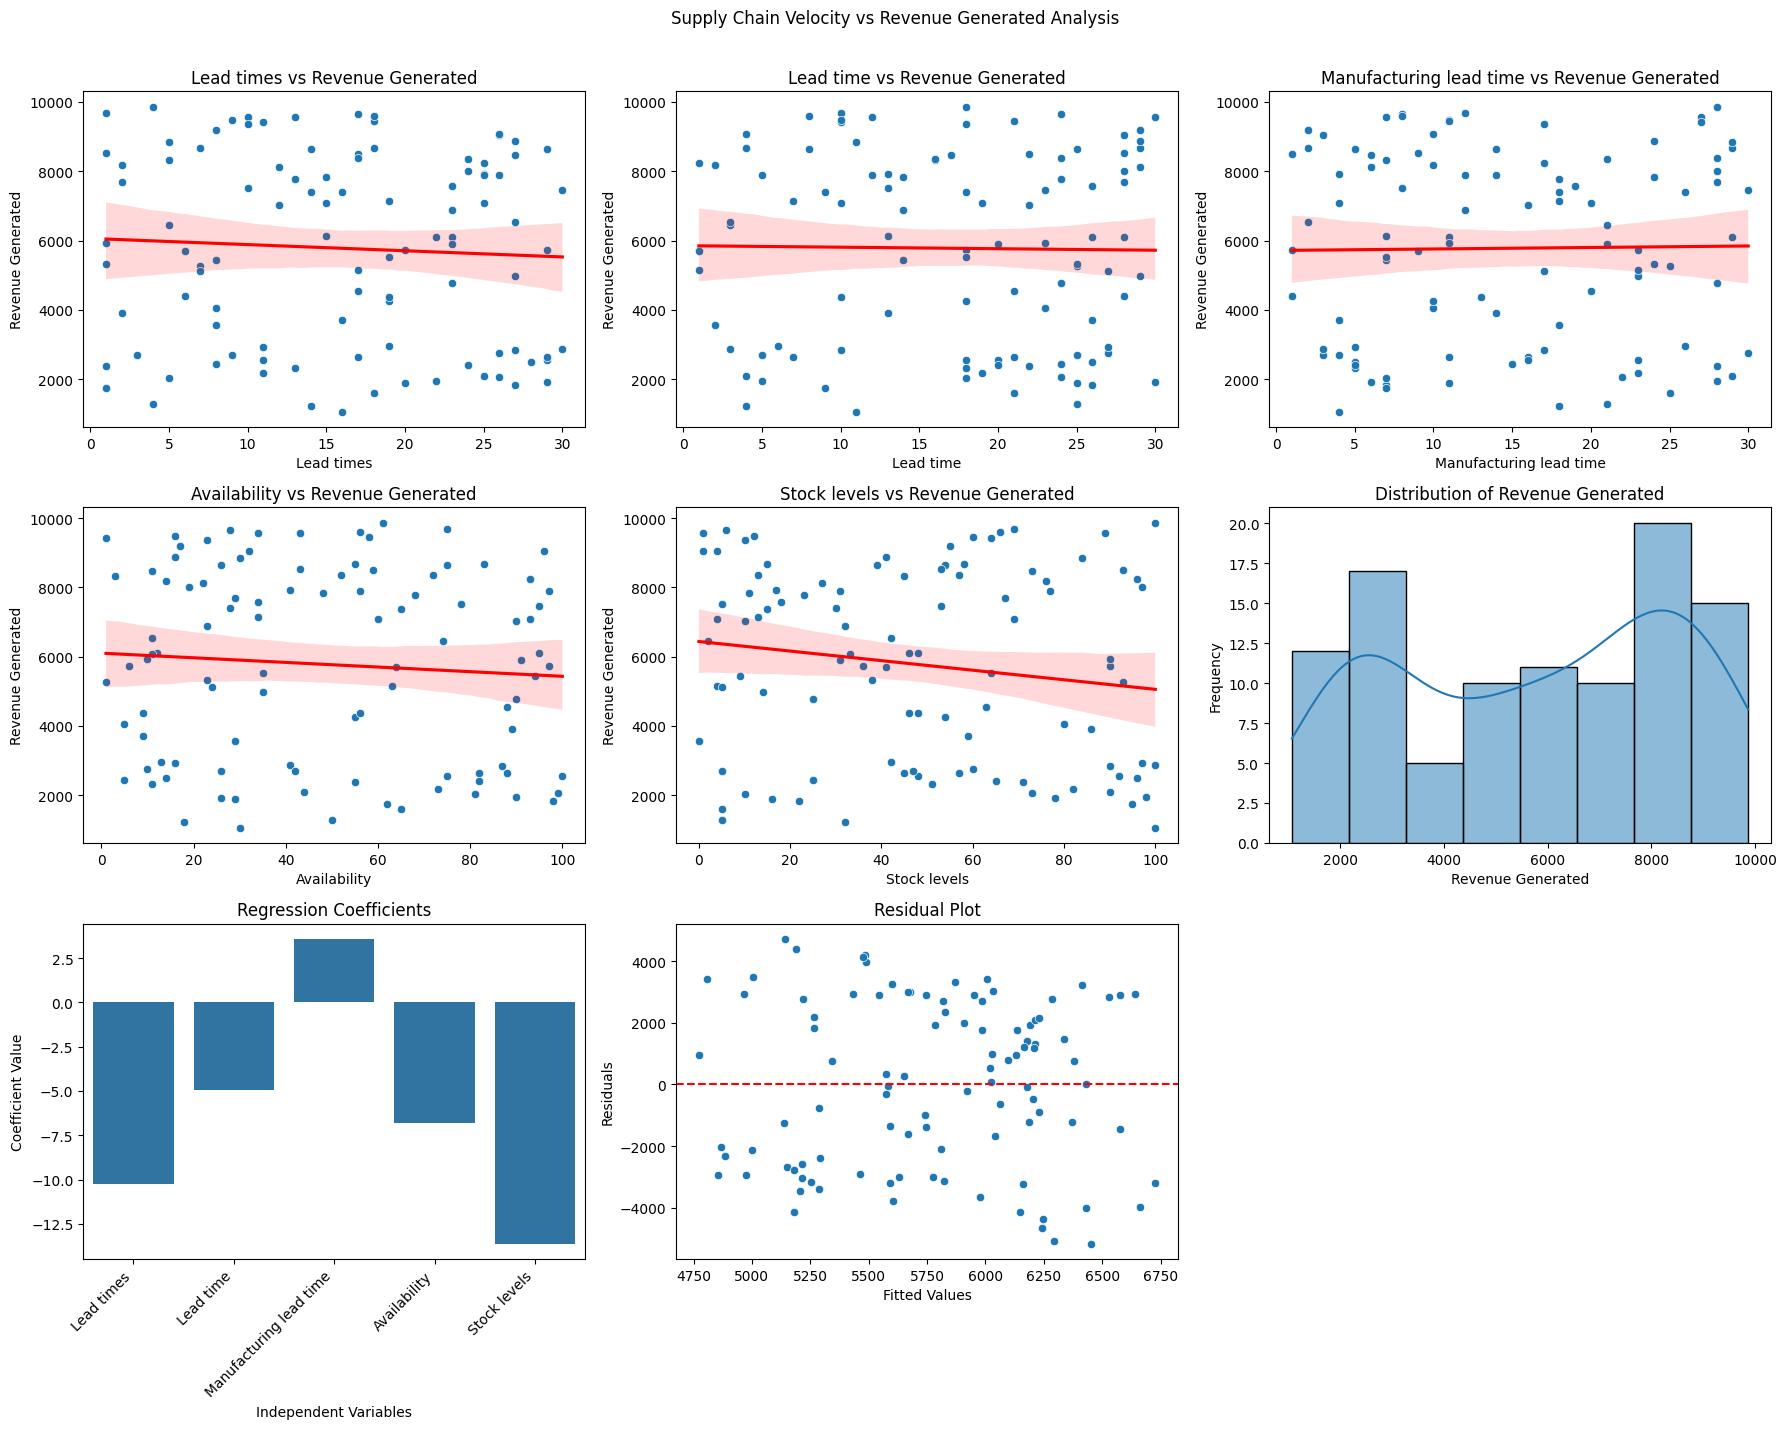

In [18]:
# --- Visualization using Matplotlib and Seaborn in Subplots ---

fig, axes = plt.subplots(3, 3, figsize=(18, 15))  # Adjust grid size to accommodate histogram
axes = axes.flatten()  # Flatten the array of axes for easy indexing

# Scatter plots with regression lines
for i, col in enumerate(independent_variables.columns):
    sns.scatterplot(x=df[col], y=dependent_variable, ax=axes[i])
    # Add regression line
    sns.regplot(x=df[col], y=dependent_variable, ax=axes[i], scatter=False, color='red')
    axes[i].set_title(f'{col} vs Revenue Generated')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Revenue Generated')

# Distribution of Revenue Generated in the next subplot
sns.histplot(dependent_variable, kde=True, ax=axes[len(independent_variables.columns)])
axes[len(independent_variables.columns)].set_title('Distribution of Revenue Generated')
axes[len(independent_variables.columns)].set_xlabel('Revenue Generated')
axes[len(independent_variables.columns)].set_ylabel('Frequency')

# Regression coefficients plot in the subsequent subplot
coefficients = model.params[1:]  # Exclude the intercept
coefficient_names = independent_variables.columns
sns.barplot(x=coefficient_names, y=coefficients, ax=axes[len(independent_variables.columns) + 1])
axes[len(independent_variables.columns) + 1].set_title('Regression Coefficients')
axes[len(independent_variables.columns) + 1].set_xlabel('Independent Variables')
axes[len(independent_variables.columns) + 1].set_ylabel('Coefficient Value')
# Instead of tick_params, use set_xticklabels to rotate and align the labels:
axes[len(independent_variables.columns) + 1].set_xticklabels(axes[len(independent_variables.columns) + 1].get_xticklabels(), rotation=45, ha='right')

# Residual plot in the next subplot
residuals = model.resid
fitted_values = model.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[len(independent_variables.columns) + 2])
axes[len(independent_variables.columns) + 2].axhline(y=0, color='r', linestyle='--')
axes[len(independent_variables.columns) + 2].set_title('Residual Plot')
axes[len(independent_variables.columns) + 2].set_xlabel('Fitted Values')
axes[len(independent_variables.columns) + 2].set_ylabel('Residuals')

# Remove any unused subplots
for j in range(len(independent_variables.columns) + 3, 9):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for suptitle
plt.suptitle('Supply Chain Velocity vs Revenue Generated Analysis', y=0.98)
plt.show()

### **3. Hypothesis: Product Quality and Customer Lifetime Value**

* H0 (Null Hypothesis): Product defect rates have no impact on customer lifetime value.

* H1 (Alternative Hypothesis): Lower product defect rates lead to higher customer lifetime value.

In [19]:
# --- Calculate a Simplified CLTV Proxy (as per your constraints) ---
hyp_3 = df.copy()  # Use a copy to avoid modifying the original df
hyp_3['CLTV_Proxy'] = hyp_3['Revenue generated']

# --- Analyze the Relationship Between Defect Rate and CLTV Proxy ---

# Group data by defect rate (or categorize defect rates)
bins = [0, 0.03, 0.06, 1.0]
labels = ['Low', 'Medium', 'High']
hyp_3['Defect Category'] = pd.cut(hyp_3['Defect rates'], bins=bins, labels=labels, right=False)

# Calculate the average CLTV proxy for each defect category
average_cltv_by_defect = hyp_3.groupby('Defect Category')['CLTV_Proxy'].mean()
print("Average CLTV Proxy by Defect Category:")
print(average_cltv_by_defect)

# --- Perform a Basic Statistical Test (Independent Samples t-test) ---

low_defect_cltv = hyp_3[hyp_3['Defect Category'] == 'Low']['CLTV_Proxy']
high_defect_cltv = hyp_3[hyp_3['Defect Category'] == 'High']['CLTV_Proxy']

t_statistic = np.nan
p_value = np.nan
alpha = 0.05

if not low_defect_cltv.empty and not high_defect_cltv.empty:
    t_statistic, p_value = stats.ttest_ind(low_defect_cltv, high_defect_cltv, equal_var=False)
    print("\nIndependent Samples t-test (Low vs. High Defect Rates):")
    print(f"T-statistic: {t_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")
    print(f"Significance level (alpha): {alpha}")

    if p_value < alpha:
        print("\nResult of Statistical Test:")
        print("Reject the null hypothesis (H0). There is statistical evidence to suggest that product defect rates have an impact on the CLTV proxy.")
        if average_cltv_by_defect.get('Low', 0) > average_cltv_by_defect.get('High', 0):
            print("The data suggests that lower product defect rates are associated with a higher CLTV proxy, supporting the alternative hypothesis (H1).")
        elif average_cltv_by_defect.get('Low', 0) < average_cltv_by_defect.get('High', 0):
            print("The data suggests that lower product defect rates are associated with a lower CLTV proxy (contrary to H1).")
        else:
            print("The data does not show a clear direction of impact between defect rates and CLTV proxy based on the averages.")
    else:
        print("\nResult of Statistical Test:")
        print("Fail to reject the null hypothesis (H0). There is not enough statistical evidence to suggest that product defect rates have a significant impact on the CLTV proxy based on this test.")
else:
    print("\nNot enough data to perform the t-test for Low and High defect categories.")

# --- Further Analysis (Correlation - be cautious with interpretation) ---
correlation = hyp_3['Defect rates'].corr(hyp_3['CLTV_Proxy'])
print(f"\nCorrelation between Defect Rate and CLTV Proxy: {correlation:.3f}")
print("Note: Correlation does not imply causation and with this simplified CLTV proxy,")
print("the interpretation should be done cautiously.")

# --- Overall Hypothesis Conclusion based on the analysis ---
print("\nOverall Hypothesis Conclusion:")
if not np.isnan(p_value) and p_value < alpha:
    if average_cltv_by_defect.get('Low', -np.inf) > average_cltv_by_defect.get('High', np.inf):
        print("Based on the statistical test and average CLTV proxy, we find evidence supporting the alternative hypothesis (H1): Lower product defect rates lead to higher customer lifetime value (as proxied by revenue per transaction).")
    else:
        print("Based on the statistical test, we reject the null hypothesis (H0), but the direction of the impact on the CLTV proxy does not clearly support the stated alternative hypothesis (H1).")
else:
    print("Based on the statistical test, we fail to reject the null hypothesis (H0): Product defect rates have no significant impact on the customer lifetime value proxy based on this analysis.")
    print("Further investigation with more comprehensive data might be needed.")

Average CLTV Proxy by Defect Category:
Defect Category
Low       6593.498406
Medium    5521.205259
High      6338.896577
Name: CLTV_Proxy, dtype: float64

Independent Samples t-test (Low vs. High Defect Rates):
T-statistic: 0.31
P-value: 0.765
Significance level (alpha): 0.05

Result of Statistical Test:
Fail to reject the null hypothesis (H0). There is not enough statistical evidence to suggest that product defect rates have a significant impact on the CLTV proxy based on this test.

Correlation between Defect Rate and CLTV Proxy: -0.125
Note: Correlation does not imply causation and with this simplified CLTV proxy,
the interpretation should be done cautiously.

Overall Hypothesis Conclusion:
Based on the statistical test, we fail to reject the null hypothesis (H0): Product defect rates have no significant impact on the customer lifetime value proxy based on this analysis.
Further investigation with more comprehensive data might be needed.


<ipython-input-19-d4bd91edf54e>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_cltv_by_defect = hyp_3.groupby('Defect Category')['CLTV_Proxy'].mean()


<ipython-input-20-757ac7bea8e1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_cltv_by_defect.index, y=average_cltv_by_defect.values, ax=axes[0], palette="viridis")
<ipython-input-20-757ac7bea8e1>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Defect Category', y='CLTV_Proxy', data=hyp_3, ax=axes[1], palette="viridis")


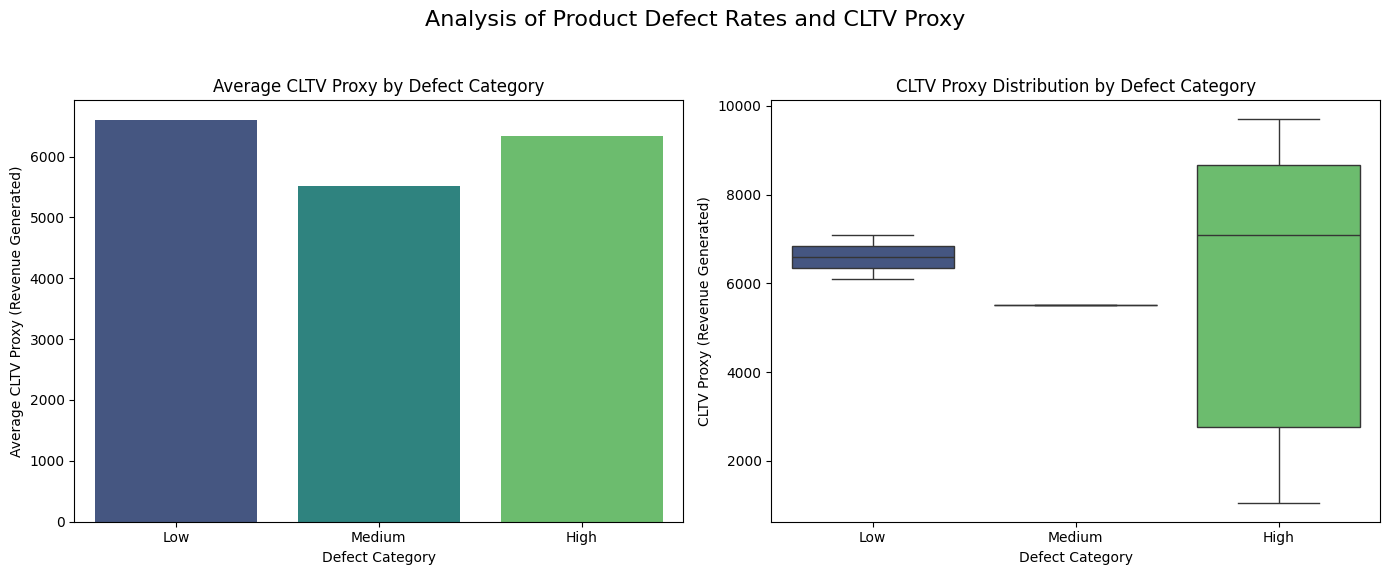

In [20]:
# --- Create Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analysis of Product Defect Rates and CLTV Proxy', fontsize=16)

# Subplot 1: Bar plot of Average CLTV Proxy by Defect Category
sns.barplot(x=average_cltv_by_defect.index, y=average_cltv_by_defect.values, ax=axes[0], palette="viridis")
axes[0].set_title('Average CLTV Proxy by Defect Category')
axes[0].set_xlabel('Defect Category')
axes[0].set_ylabel('Average CLTV Proxy (Revenue Generated)')

# Subplot 2: Box plot of CLTV Proxy by Defect Category
sns.boxplot(x='Defect Category', y='CLTV_Proxy', data=hyp_3, ax=axes[1], palette="viridis")
axes[1].set_title('CLTV Proxy Distribution by Defect Category')
axes[1].set_xlabel('Defect Category')
axes[1].set_ylabel('CLTV Proxy (Revenue Generated)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## **Results**

* Skincare is the top performer in both sales volume and revenue, especially among female customers, indicating a strong market demand in Kolkata.

* While Haircare and Cosmetics have lower sales volumes, their higher revenue percentage suggests better pricing or margins, presenting a potential area for profitability focus, though male and non-binary haircare sales are notably lower.

* Hypothesis testing reveals no statistically significant linear relationship between integrated cost efficiency and average customer revenue, nor between supply chain velocity and overall sales revenue, suggesting these factors may not be directly driving the outcomes as initially hypothesized in this dataset.

## **Recommendations on Basis Analysis**

* Prioritize and invest in the skincare category, particularly targeting the female demographic and the Kolkata market, to leverage its strong performance.

* Strategically evaluate pricing and margin opportunities within the Haircare and Cosmetics categories to potentially boost overall profitability, while exploring strategies to improve Haircare sales among male and non-binary customers.

* Further investigate the drivers of customer revenue and sales beyond integrated cost efficiency and supply chain velocity, considering other factors not included in these initial hypothesis tests.